In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)

print("\nMatches columns:")
print(matches.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)

Matches columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [3]:
# Check dataset sizes
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

# Check data types and missing values
print("\nMatches information:")
matches.info()

print("\nMissing values in matches:")
print(matches.isnull().sum())

print("\nMissing values in deliveries:")
print(deliveries.isnull().sum())

# View basic statistics
display(matches.describe(include="all").T)
display(deliveries.describe().T)

Matches: (1095, 20)
Deliveries: (260920, 17)

Matches information:
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  supe

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1095.0,NaN,NaN,NaN,904828.319635,367740.242299,335982.0,548331.5,980961.0,1254062.5,1426312.0
season,1095,17,2013,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1044,36,Mumbai,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1095,823,2008-04-19,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,1095,8,League,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_of_match,1090,291,AB de Villiers,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,1095,58,Eden Gardens,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1095,19,Royal Challengers Bangalore,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1095,19,Mumbai Indians,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1095,19,Mumbai Indians,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
match_id,260920.0,907066.506086,367991.278255,335982.0,548334.0,980967.0,1254066.0,1426312.0
inning,260920.0,1.483531,0.502643,1.0,1.0,1.0,2.0,6.0
over,260920.0,9.197677,5.683484,0.0,4.0,9.0,14.0,19.0
ball,260920.0,3.624486,1.814920,1.0,2.0,4.0,5.0,11.0
batsman_runs,260920.0,1.265001,1.639298,0.0,0.0,1.0,1.0,6.0
extra_runs,260920.0,0.067806,0.343265,0.0,0.0,0.0,0.0,7.0
total_runs,260920.0,1.332807,1.626416,0.0,0.0,1.0,1.0,7.0
is_wicket,260920.0,0.049632,0.217184,0.0,0.0,0.0,0.0,1.0


,Number of Matches
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


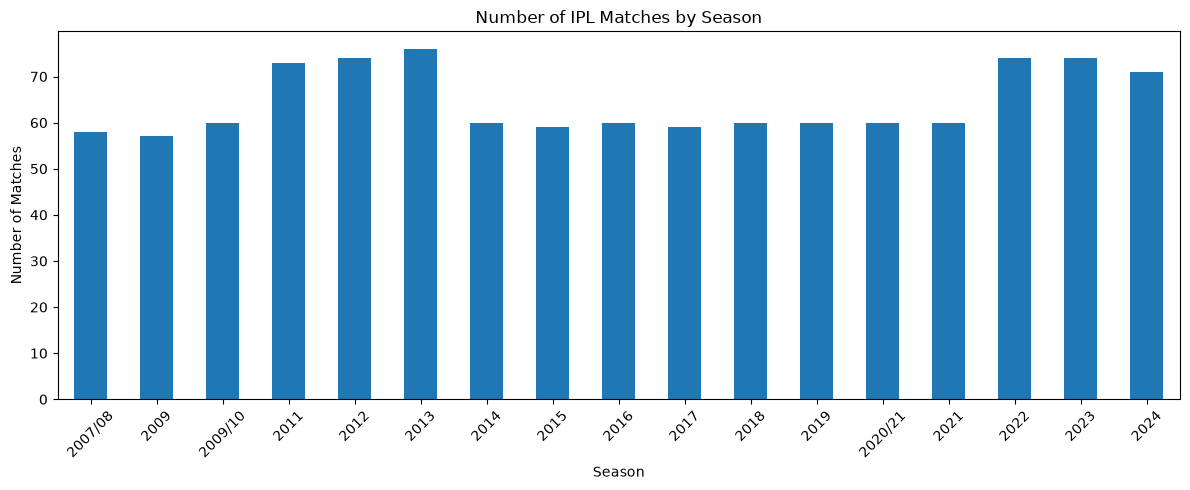

In [12]:
# Count matches in each IPL season
season_counts = matches["season"].value_counts().sort_index()

display(season_counts.rename("Number of Matches").to_frame())

# Create a bar chart
plt.figure(figsize=(12, 5))
season_counts.plot(kind="bar")

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../results/matches_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

,Wins
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Kings XI Punjab,88
Sunrisers Hyderabad,88
Delhi Daredevils,67
Delhi Capitals,48


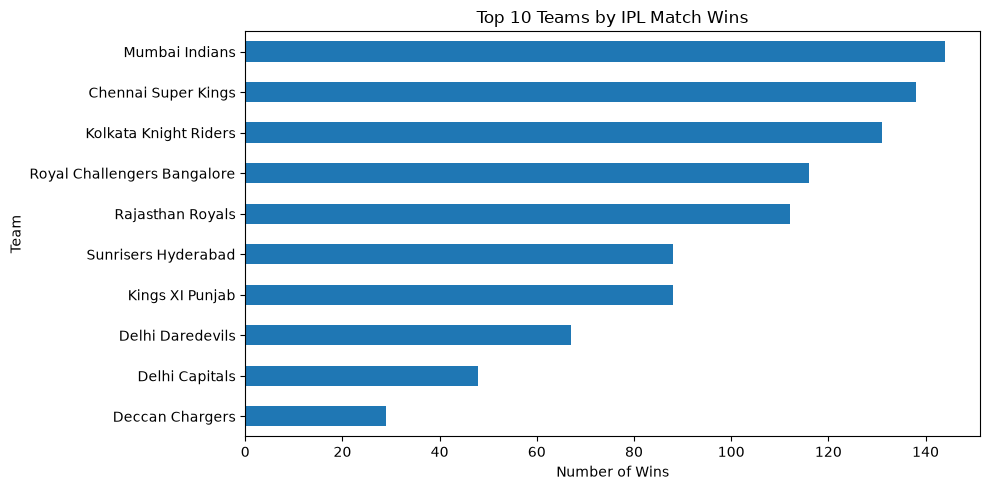

In [13]:
# Find the number of wins for each team
team_wins = matches["winner"].value_counts().head(10)

display(team_wins.rename("Wins").to_frame())

# Plot the top 10 teams
plt.figure(figsize=(10, 5))
team_wins.sort_values().plot(kind="barh")

plt.title("Top 10 Teams by IPL Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.savefig("../results/team_wins.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Identify the batter column
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


,Total Runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


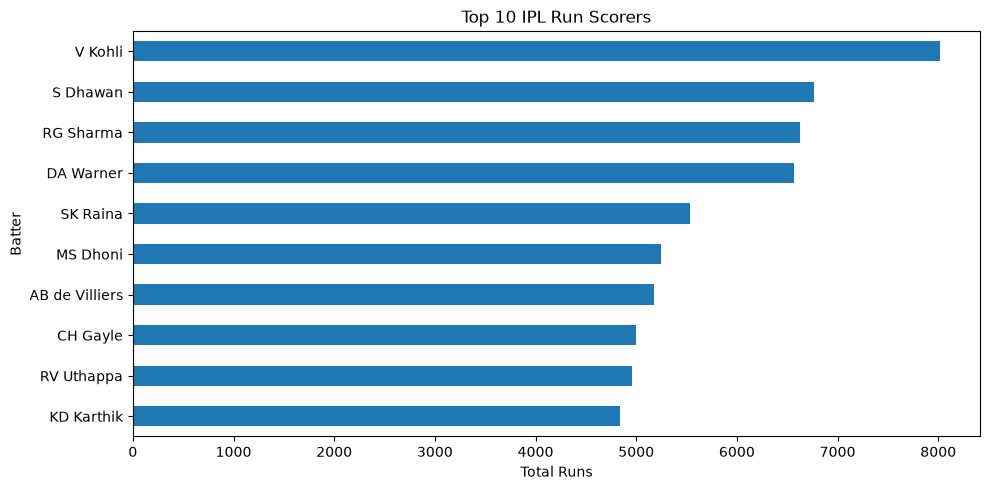

In [14]:
top_batters = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_batters.rename("Total Runs").to_frame())

top_batters.sort_values().plot(kind="barh", figsize=(10, 5))
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Batter")
plt.tight_layout()
plt.savefig("../results/top_run_scorers.png", dpi=300, bbox_inches="tight")
plt.show()

Toss decisions:


toss_decision
field    704
bat      391
Name: count, dtype: int64

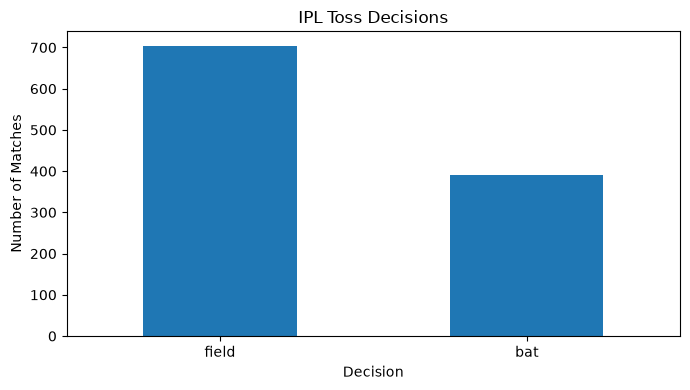

In [16]:
# Most common toss decisions
print("Toss decisions:")
display(matches["toss_decision"].value_counts())

# Toss decision chart
matches["toss_decision"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("IPL Toss Decisions")
plt.xlabel("Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/toss_decisions.png",dpi=300, bbox_inches="tight")
plt.show()

,Wickets
bowler,
YS Chahal,205
PP Chawla,192
DJ Bravo,183
B Kumar,181
R Ashwin,180
SP Narine,180
A Mishra,174
SL Malinga,170
JJ Bumrah,168


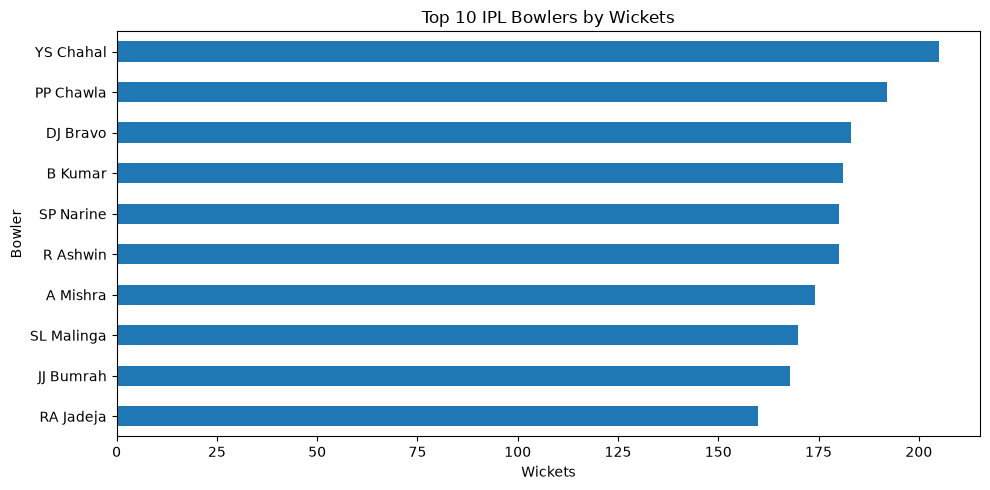

In [15]:
# Exclude dismissals that are generally not credited to the bowler
non_bowler_dismissals = [
    "run out",
    "retired hurt",
    "obstructing the field",
    "retired out"
]

bowler_wickets = deliveries[
    deliveries["dismissal_kind"].notna()
    & ~deliveries["dismissal_kind"].isin(non_bowler_dismissals)
].groupby("bowler")["dismissal_kind"].count()

top_bowlers = bowler_wickets.sort_values(
    ascending=False
).head(10)

display(top_bowlers.rename("Wickets").to_frame())

top_bowlers.sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Top 10 IPL Bowlers by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.tight_layout()
plt.savefig("../results/top_wicket_takers.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
toss_match_wins = (
    matches["toss_winner"] == matches["winner"]
).sum()

total_matches = matches["winner"].notna().sum()

percentage = toss_match_wins / total_matches * 100

print("Matches with a recorded winner:", total_matches)
print("Matches where toss winner also won:", toss_match_wins)
print(f"Percentage: {percentage:.2f}%")

Matches with a recorded winner: 1090
Matches where toss winner also won: 554
Percentage: 50.83%


In [ ]:
print("========== IPL PROJECT FINDINGS ==========")

print(f"\nTotal matches: {len(matches)}")
print(f"Total deliveries: {len(deliveries)}")

print("\n1. Matches by season:")
print(matches["season"].value_counts().sort_index())

print("\n2. Top 5 teams by wins:")
print(matches["winner"].value_counts().head(5))

print("\n3. Top 5 run scorers:")
batter_col = "batter" if "batter" in deliveries.columns else "batsman"

print(
    deliveries.groupby(batter_col)["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\n4. Toss decisions:")
print(matches["toss_decision"].value_counts())

print("\n5. Top 5 Player of the Match award winners:")
print(matches["player_of_match"].value_counts().head(5))

========== IPL PROJECT FINDINGS ==========

Total matches: 1095
Total deliveries: 260920

1. Matches by season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64

2. Top 5 teams by wins:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: count, dtype: int64

3. Top 5 run scorers:
batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64

4. Toss decisions:
toss_decision
field    704
bat      391
Name: count, dtype: int64

5. Top 5 Player of the Match award winners:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
